# BART Text Simplification – Clean Notebook

Notebook ini berisi pipeline pelatihan dan evaluasi model BART untuk text simplification dengan konfigurasi anti-overfitting.

In [1]:
# CELL 1: Dependencies Installation
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

!pip install -q transformers datasets accelerate
!pip install -q sacrebleu
!pip install -q "git+https://github.com/feralvam/easse"
!pip install -q nltk
!pip install -q textstat
!pip install -q tqdm

print("Cell 1 complete: dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.6 MB/s eta 0:00:00
Cell 1 complete: dependencies installed.


In [2]:
!pip install protobuf

In [3]:
# CELL 2: Imports and Environment Setup
import re
import hashlib
import logging
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from pathlib import Path
from collections import OrderedDict
import json
import gc

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm
from datasets import load_dataset, DatasetDict, Dataset
from transformers import (
    BartTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq, Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, set_seed
)

import sacrebleu
from sacrebleu import corpus_bleu
from easse.sari import corpus_sari, get_corpus_sari_operation_scores

import nltk
try:
    nltk.data.find('wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)

import textstat

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Global variable to hold current sources for metrics
CURRENT_SOURCES = None

print("Cell 2 complete: imports and environment ready.")

2025-12-18 15:02:51.417851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766070171.579361      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766070171.626662      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766070171.998150      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766070171.998201      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766070171.998204      25 computation_placer.cc:177] computation placer alr

Device: cuda
PyTorch version: 2.8.0+cu126
GPU memory: 17.06 GB
Cell 2 complete: imports and environment ready.


In [4]:
# CELL 3: Configuration (Anti-Overfitting)
@dataclass
class Config:
    # Model configuration
    model_name: str = "facebook/bart-base"
    max_input_length: int = 128
    max_target_length: int = 128
    

    warmup_ratio: float = 0.15
    weight_decay: float = 0.01
    
    # Regularization
    dropout: float = 0.2
    attention_dropout: float = 0
    label_smoothing: float = 0.1
    
    # Model optimization
    use_gradient_checkpointing: bool = True
    fp16: bool = torch.cuda.is_available()
    
    # Data filtering flags
    use_lexical_filtering: bool = True
    filter_by_replacement: bool = True
    filter_by_deletion: bool = True
    filter_by_overlap: bool = True
    filter_by_length_ratio: bool = True
    
    # Filtering thresholds
    min_length_ratio: float = 0.5
    max_length_ratio: float = 1.2
    min_replacement_rate: float = 0.10
    max_deletion_rate: float = 0.50
    min_overlap: float = 0.40
    max_overlap: float = 0.90
    min_substitution_score: float = 0.3
    
    # Early stopping & evaluation
    output_dir: str = "/kaggle/working/bart_simplify_improved"
    early_stopping_patience: int = 10
    eval_steps: int = 200
    logging_steps: int = 200
    save_total_limit: int = 3
    
    seed: int = 42
    experiment_name: str = "improved_lexical_substitution"
    

config = Config()
set_seed(config.seed)

print("Cell 3 complete: configuration created.")

Cell 3 complete: configuration created.


In [5]:
# CELL 4: Data Processor
class EnhancedDataProcessor:
    """Enhanced data processor with conditional filtering."""
    
    PTB_PATTERNS = [
        (r'\b-?lrb-?\b', '('),
        (r'\b-?rrb-?\b', ')'),
        (r'\b-?lsb-?\b', '['),
        (r'\b-?rsb-?\b', ']'),
        (r'\b-?lcb-?\b', '{'),
        (r'\b-?rcb-?\b', '}'),
        (r'\s+-lrb-\s+', ' ('),
        (r'\s+-rrb-\s+', ') '),
        (r'\s+lrb\s+', ' ('),
        (r'\s+rrb\s+', ') '),
        (r'^-?lrb-?\s*', ''),
        (r'\s*-?rrb-?$', ''),
    ]
    
    @staticmethod
    def normalize_text(text: str) -> str:
        """Normalize text with PTB pattern handling."""
        if not text:
            return ""
        
        text = text.strip()
        
        for _ in range(2):
            for pattern, replacement in EnhancedDataProcessor.PTB_PATTERNS:
                text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
        
        text = re.sub(r'\(\s*(?=\s|$)', '', text)
        text = re.sub(r'(?<=\s)\s*\)', '', text)
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\s+([,.!?;:])', r'\1', text)
        text = re.sub(r'([,.!?;:])\s*', r'\1 ', text)
        text = re.sub(r'\(\s+', '(', text)
        text = re.sub(r'\s+\)', ')', text)
        text = re.sub(r'\)\s*([,;:])', r') \1', text)
        
        sentences = re.split(r'(?<=[.!?])\s+', text)
        sentences = [s.strip() for s in sentences if s.strip()]
        sentences = [s[0].upper() + s[1:] if len(s) > 0 else s for s in sentences]
        text = ' '.join(sentences)
        
        if text and text[-1] not in '.!?':
            text += '.'
        
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    @staticmethod
    def measure_lexical_substitution(src: str, tgt: str) -> Optional[dict]:
        """Measure lexical substitution metrics."""
        src_words = src.lower().split()
        tgt_words = tgt.lower().split()
        
        src_set = set(src_words)
        tgt_set = set(tgt_words)
        
        if len(src_words) == 0 or len(tgt_words) == 0:
            return None
        
        kept_words = src_set & tgt_set
        deleted_words = src_set - tgt_set
        added_words = tgt_set - src_set
        
        overlap = len(kept_words) / len(src_set)
        deletion_rate = len(deleted_words) / len(src_set)
        replacement_rate = len(added_words) / max(len(tgt_set), 1)
        substitution_score = len(added_words) / max(len(deleted_words), 1)
        
        return {
            "overlap": overlap,
            "deletion_rate": deletion_rate,
            "replacement_rate": replacement_rate,
            "substitution_score": substitution_score,
            "kept_words": len(kept_words),
            "deleted_words": len(deleted_words),
            "added_words": len(added_words),
        }
    
    @staticmethod
    def is_lexical_substitution(ex, config: Config) -> bool:
        """Conditional filtering based on configuration flags."""
        src = ex["source"].strip()
        tgt = ex["target"].strip()
        
        if not src or not tgt:
            return False
        if src.lower() == tgt.lower():
            return False
        
        if not config.use_lexical_filtering:
            return True
        
        metrics = EnhancedDataProcessor.measure_lexical_substitution(src, tgt)
        if metrics is None:
            return False
        
        if config.filter_by_replacement:
            if metrics["replacement_rate"] < config.min_replacement_rate:
                return False
        
        if config.filter_by_deletion:
            if metrics["deletion_rate"] > config.max_deletion_rate:
                return False
            if metrics["substitution_score"] < config.min_substitution_score:
                return False
        
        if config.filter_by_overlap:
            if metrics["overlap"] < config.min_overlap or metrics["overlap"] > config.max_overlap:
                return False
        
        if config.filter_by_length_ratio:
            src_len = len(src.split())
            tgt_len = len(tgt.split())
            ratio = tgt_len / src_len if src_len > 0 else 0
            
            if ratio < config.min_length_ratio or ratio > config.max_length_ratio:
                return False
        
        return True
    
    @staticmethod
    def deduplicate_dataset(dataset: Dataset) -> Dataset:
        """Remove duplicate examples."""
        seen_pairs = set()
        
        def filter_fn(example, idx):
            src = example.get("source", "")
            tgt = example.get("target", "")
            
            pair_hash = hashlib.md5(f"{src}||{tgt}".encode()).hexdigest()
            if pair_hash in seen_pairs:
                return False
            
            seen_pairs.add(pair_hash)
            return True
        
        return dataset.filter(filter_fn, with_indices=True)

print("Cell 4 complete: data processor ready.")

Cell 4 complete: data processor ready.


In [6]:
# CELL 5: Load and Filter Dataset
print("Loading WikiLarge dataset...")
raw_dataset = load_dataset("bogdancazan/wikilarge-text-simplification")

print("\nOriginal dataset sizes:")
for split in raw_dataset:
    print(f"  {split}: {len(raw_dataset[split]):,}")

def preprocess_fn(examples):
    sources = [EnhancedDataProcessor.normalize_text(s) for s in examples.get("Normal", examples.get("source", []))]
    targets = [EnhancedDataProcessor.normalize_text(t) for t in examples.get("Simple", examples.get("target", []))]
    return {"source": sources, "target": targets}

print("\nNormalizing text...")
dataset = raw_dataset.map(preprocess_fn, batched=True, num_proc=4)

if config.use_lexical_filtering:
    print("\nApplying conditional filtering on train and validation splits...")
    
    for split in ["train", "validation"]:
        if split in dataset:
            before = len(dataset[split])
            dataset[split] = dataset[split].filter(
                lambda ex: EnhancedDataProcessor.is_lexical_substitution(ex, config),
                desc=f"Filtering {split}"
            )
            after = len(dataset[split])
            pct_kept = 100 * after / before if before > 0 else 0
            print(f"  {split}: {before:,} -> {after:,} (kept {pct_kept:.1f}%)")
else:
    print("\nFiltering disabled: using all data.")

print("\nSample training examples:")
for i in range(min(3, len(dataset["train"]))):
    ex = dataset["train"][i]
    print(f"\nExample {i+1}:")
    print(f"  Source: {ex['source'][:80]}...")
    print(f"  Target: {ex['target'][:80]}...")

CURRENT_SOURCES = dataset["validation"]["source"]

print("\nCell 5 complete: dataset loaded and filtered.")

Loading WikiLarge dataset...


wiki.full.aner.ori.train.95.tsv:   0%|          | 0.00/36.3M [00:00<?, ?B/s]

wiki.full.aner.ori.valid.95.tsv: 0.00B [00:00, ?B/s]

wiki.full.aner.ori.test.95.tsv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/148843 [00:00<?, ? examples/s]

...


Applying conditional filtering on train and validation splits...


Filtering train:   0%|          | 0/148843 [00:00<?, ? examples/s]

  train: 148,843 -> 52,095 (kept 35.0%)


Filtering validation:   0%|          | 0/494 [00:00<?, ? examples/s]

  validation: 494 -> 169 (kept 34.2%)

Sample training examples:

Example 1:
  Source: There is manuscript evidence that austen continued to work on these pieces as la...
  Target: There is some proof that austen continued to work on these pieces later in life....

Example 2:
  Source: When japan earned another race on the f schedule ten years later it went to suzu...
  Target: When japan was added back to the f schedule ten years later it went to suzuka in...

Example 3:
  Source: Ka la ku oko a hawaiian independence day the kingdom of hawai i is officially re...
  Target: November ka la ku oko a hawaiian independence day. The kingdom of hawai i was of...

Cell 5 complete: dataset loaded and filtered.


In [7]:
# CELL 6: Tokenization
print("Loading tokenizer...")
tokenizer = BartTokenizer.from_pretrained(config.model_name, use_fast=True)

def tokenize_fn(examples):
    model_inputs = tokenizer(
        examples["source"],
        max_length=config.max_input_length,
        truncation=True,
    )
    
    labels = tokenizer(
        examples["target"],
        max_length=config.max_target_length,
        truncation=True,
    )
    
    model_inputs["labels"] = labels["input_ids"]
    model_inputs["source_text"] = examples["source"]
    model_inputs["target_text"] = examples["target"]
    
    return model_inputs

print("Tokenizing datasets...")
tokenized_dataset = dataset.map(
    tokenize_fn,
    batched=True,
    num_proc=4,
    remove_columns=["source", "target"],
    desc="Tokenizing"
)

print("\nTokenized dataset:")
print(tokenized_dataset)
print("\nCell 6 complete: tokenization done.")

Loading tokenizer...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


Tokenizing (num_proc=4):   0%|          | 0/52095 [00:00<?, ? examples/s]

Tokenizing (num_proc=4):   0%|          | 0/169 [00:00<?, ? examples/s]

Tokenizing (num_proc=4):   0%|          | 0/191 [00:00<?, ? examples/s]


Tokenized dataset:
DatasetDict({
    train: Dataset({
        features: ['Normal', 'Simple', 'input_ids', 'attention_mask', 'labels', 'source_text', 'target_text'],
        num_rows: 52095
    })
    validation: Dataset({
        features: ['Normal', 'Simple', 'input_ids', 'attention_mask', 'labels', 'source_text', 'target_text'],
        num_rows: 169
    })
    test: Dataset({
        features: ['Normal', 'Simple', 'input_ids', 'attention_mask', 'labels', 'source_text', 'target_text'],
        num_rows: 191
    })
})

Cell 6 complete: tokenization done.


In [8]:
# CELL 7: Model Loading with Regularization
print(f"Loading model: {config.model_name}")
model = AutoModelForSeq2SeqLM.from_pretrained(config.model_name)

# Apply dropout regularization
print("Applying dropout and regularization settings...")
model.config.dropout = config.dropout
model.config.attention_dropout = config.attention_dropout
model.config.activation_dropout = config.dropout

for module in model.modules():
    if isinstance(module, torch.nn.Dropout):
        module.p = config.dropout

if config.use_gradient_checkpointing:
    model.gradient_checkpointing_enable()
    print("Gradient checkpointing enabled.")

# Generation configuration
model.config.max_length = 100
model.config.min_length = 20
model.config.length_penalty = 1.0
model.config.num_beams = 5
model.config.early_stopping = True
model.config.no_repeat_ngram_size = 3

model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print("\nModel statistics:")
print(f"  Parameters: {total_params:,}")
print(f"  Approximate size: {total_params * 4 / 1e9:.2f} GB")

print("\nCell 7 complete: model loaded and configured.")

Loading model: facebook/bart-base


model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Applying dropout and regularization settings...
Gradient checkpointing enabled.

Model statistics:
  Parameters: 139,420,416
  Approximate size: 0.56 GB

Cell 7 complete: model loaded and configured.


In [9]:
# CELL 8: Metrics Functions (PERBAIKAN)
def calculate_fkgl_improvement(sources, predictions):
    """Calculate FKGL improvement metrics."""
    src_fkgl_scores = []
    pred_fkgl_scores = []
    
    for src, pred in zip(sources, predictions):
        if src and pred:
            try:
                src_fkgl = textstat.flesch_kincaid_grade(src)
                pred_fkgl = textstat.flesch_kincaid_grade(pred)
                
                if src_fkgl > 0 and pred_fkgl > 0:
                    src_fkgl_scores.append(src_fkgl)
                    pred_fkgl_scores.append(pred_fkgl)
            except Exception:
                continue
    
    if not src_fkgl_scores:
        return {
            "fkgl_source": 0.0,
            "fkgl_prediction": 0.0,
            "fkgl_improvement": 0.0,
        }
    
    avg_src_fkgl = sum(src_fkgl_scores) / len(src_fkgl_scores)
    avg_pred_fkgl = sum(pred_fkgl_scores) / len(pred_fkgl_scores)
    fkgl_improvement = avg_src_fkgl - avg_pred_fkgl
    
    return {
        "fkgl_source": round(avg_src_fkgl, 2),
        "fkgl_prediction": round(avg_pred_fkgl, 2),
        "fkgl_improvement": round(fkgl_improvement, 2),
    }

def compute_metrics(eval_pred):
    """Metrics calculation with SARI, BLEU, and FKGL."""
    global CURRENT_SOURCES

    predictions, labels = eval_pred
    
    # --- BAGIAN PERBAIKAN DI SINI ---
    # Ganti -100 pada predictions dengan pad_token_id agar tokenizer tidak error
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    # --------------------------------
    
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    
    # Membersihkan labels (ini sudah benar di kode lama, tapi pastikan tetap ada)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    
    if CURRENT_SOURCES is None:
        # Fallback jika CURRENT_SOURCES belum di-set (mencegah error lain)
        print("Warning: CURRENT_SOURCES is None. Using empty list.")
        sources = [""] * len(decoded_preds)
    else:
        sources = CURRENT_SOURCES[: len(decoded_preds)]
    
    try:
        bleu = corpus_bleu(decoded_preds, [decoded_labels]).score
    except Exception:
        bleu = 0.0
    
    try:
        add_score, keep_score, delete_score = get_corpus_sari_operation_scores(
            sources, decoded_preds, [decoded_labels]
        )
        sari_score = (add_score + keep_score + delete_score) / 3
        
        substitution_quality = (add_score * 1.5 + keep_score - delete_score * 0.5) / 3
        
        fkgl_metrics = calculate_fkgl_improvement(sources, decoded_preds)
        
        return {
            "bleu": round(bleu, 2),
            "sari_add": round(add_score, 2),
            "sari_keep": round(keep_score, 2),
            "sari_delete": round(delete_score, 2),
            "sari": round(sari_score, 2),
            "substitution_quality": round(substitution_quality, 2),
            "fkgl_source": fkgl_metrics["fkgl_source"],
            "fkgl_prediction": fkgl_metrics["fkgl_prediction"],
            "fkgl_improvement": fkgl_metrics["fkgl_improvement"],
        }
    except Exception as e:
        print(f"Warning in metrics calculation: {e}")
        # Fallback values
        return {
            "bleu": 0.0,
            "sari": 0.0,
            "fkgl_improvement": 0.0,
        }

print("Cell 8 complete: metrics functions fixed.")

Cell 8 complete: metrics functions fixed.


In [10]:
# CELL 9: Training Setup (PERBAIKAN)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bart_simplification_scenario_2_improved",
    
    # --- PENGATURAN BATCH SIZE OPTIMAL ---
    per_device_train_batch_size=8,   # VRAM aman
    per_device_eval_batch_size=8,    
    gradient_accumulation_steps=1,   # 8 x 8 = 64 (Effective Batch Size)
    # -------------------------------------

    # --- HYPERPARAMETERS ---
    learning_rate=5e-5,
    weight_decay=0.01,
    num_train_epochs=10,             
    
    # --- EVALUASI & PENYIMPANAN ---
    eval_strategy="steps",     
    eval_steps=1000,                  
    save_strategy="steps",            
    save_steps=1000,
    logging_strategy="steps",        # Disamakan strateginya
    logging_steps=1000,                # Pastikan hardcoded atau config ada
    logging_first_step=True,
    
    # --- STRATEGI MODEL TERBAIK (SARI) ---
    load_best_model_at_end=True,     
    metric_for_best_model="sari",    # Fokus ke kualitas simplifikasi
    greater_is_better=True,          # SARI makin tinggi makin bagus
    save_total_limit=2,              
    
    # --- GENERATION CONFIG ---
    predict_with_generate=True,      # Wajib untuk hitung SARI/BLEU saat eval
    generation_max_length=100,
    generation_num_beams=5,          # Saya pilih 5 (lebih bagus dari 4)
    fp16=True,                       # GPU Acceleration
    
    # --- LAIN-LAIN ---
    report_to="none",                # Matikan wandb/mlflow jika tidak pakai
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    
    # --- REPRODUCIBILITY ---
    # Pastikan object 'config' sudah didefinisikan di cell sebelumnya
    # Jika error, ganti 'config.seed' dengan angka manual misal 42
    seed=42,                         
    data_seed=42,
)

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    padding=True,
    pad_to_multiple_of=8 if training_args.fp16 else None, # Pakai training_args.fp16 biar aman
)



trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Cell 9 complete: trainer initialized.")
print("Training configuration summary:")
print(f"  Train samples: {len(tokenized_dataset['train']):,}")
print(f"  Effective Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Target Metric: {training_args.metric_for_best_model}")

Cell 9 complete: trainer initialized.
Training configuration summary:
  Train samples: 52,095
  Effective Batch Size: 8
  Target Metric: sari


/tmp/ipykernel_25/455531706.py:59: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [11]:
# CELL 10: Training
print("Starting training...")
train_result = trainer.train()

print("\nTraining complete.")
print(f"Total training time (hours): {train_result.metrics['train_runtime'] / 3600:.2f}")
print(f"Final train loss: {train_result.metrics['train_loss']:.4f}")

if hasattr(trainer.state, "best_metric"):
    print(f"Best eval loss: {trainer.state.best_metric:.4f}")
    print(f"Best checkpoint path: {trainer.state.best_model_checkpoint}")

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()
    print("GPU cache cleared.")

print("Cell 10 complete: training finished.")

Starting training...


Step,Training Loss,Validation Loss,Bleu,Sari Add,Sari Keep,Sari Delete,Sari,Substitution Quality,Fkgl Source,Fkgl Prediction,Fkgl Improvement
1000,1.480100,1.330127,47.450000,13.270000,64.600000,35.680000,37.850000,22.220000,12.020000,10.750000,1.270000
2000,1.355200,1.306041,45.580000,13.510000,64.720000,37.040000,38.430000,22.160000,12.020000,10.770000,1.250000
3000,1.321200,1.288405,44.800000,11.890000,64.540000,36.580000,37.670000,21.360000,12.020000,10.960000,1.060000
4000,1.313100,1.256700,45.390000,13.040000,64.430000,38.950000,38.810000,21.500000,12.020000,10.710000,1.310000
5000,1.273300,1.262886,45.660000,12.480000,65.260000,39.480000,39.070000,21.410000,12.090000,10.270000,1.820000
6000,1.257200,1.255901,45.490000,14.350000,65.180000,41.940000,40.490000,21.910000,12.020000,9.820000,2.200000
7000,1.149400,1.237610,45.410000,14.360000,65.120000,42.770000,40.750000,21.760000,12.020000,10.360000,1.660000
8000,1.058500,1.233922,45.390000,13.940000,65.930000,45.190000,41.690000,21.420000,12.090000,10.500000,1.590000
9000,1.058500,1.244937,45.400000,14.470000,65.010000,43.920000,41.140000,21.590000,12.020000,10.470000,1.550000
10000,1.056600,1.237400,44.790000,15.160000,65.550000,46.630000,42.450000,21.660000,12.020000,9.480000,2.540000


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 100, 'min_length': 20, 'early_stopping': True, 'num_beams': 5, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].



Training complete.
Total training time (hours): 2.31
Final train loss: 0.6617
Best eval loss: 50.2300
Best checkpoint path: ./bart_simplification_scenario_2_improved/checkpoint-54000
GPU cache cleared.
Cell 10 complete: training finished.


Generating metrics visualization based on MAX SARI...
Plot saved to: /kaggle/working/bart_simplify_improved/training_metrics_best_sari.png


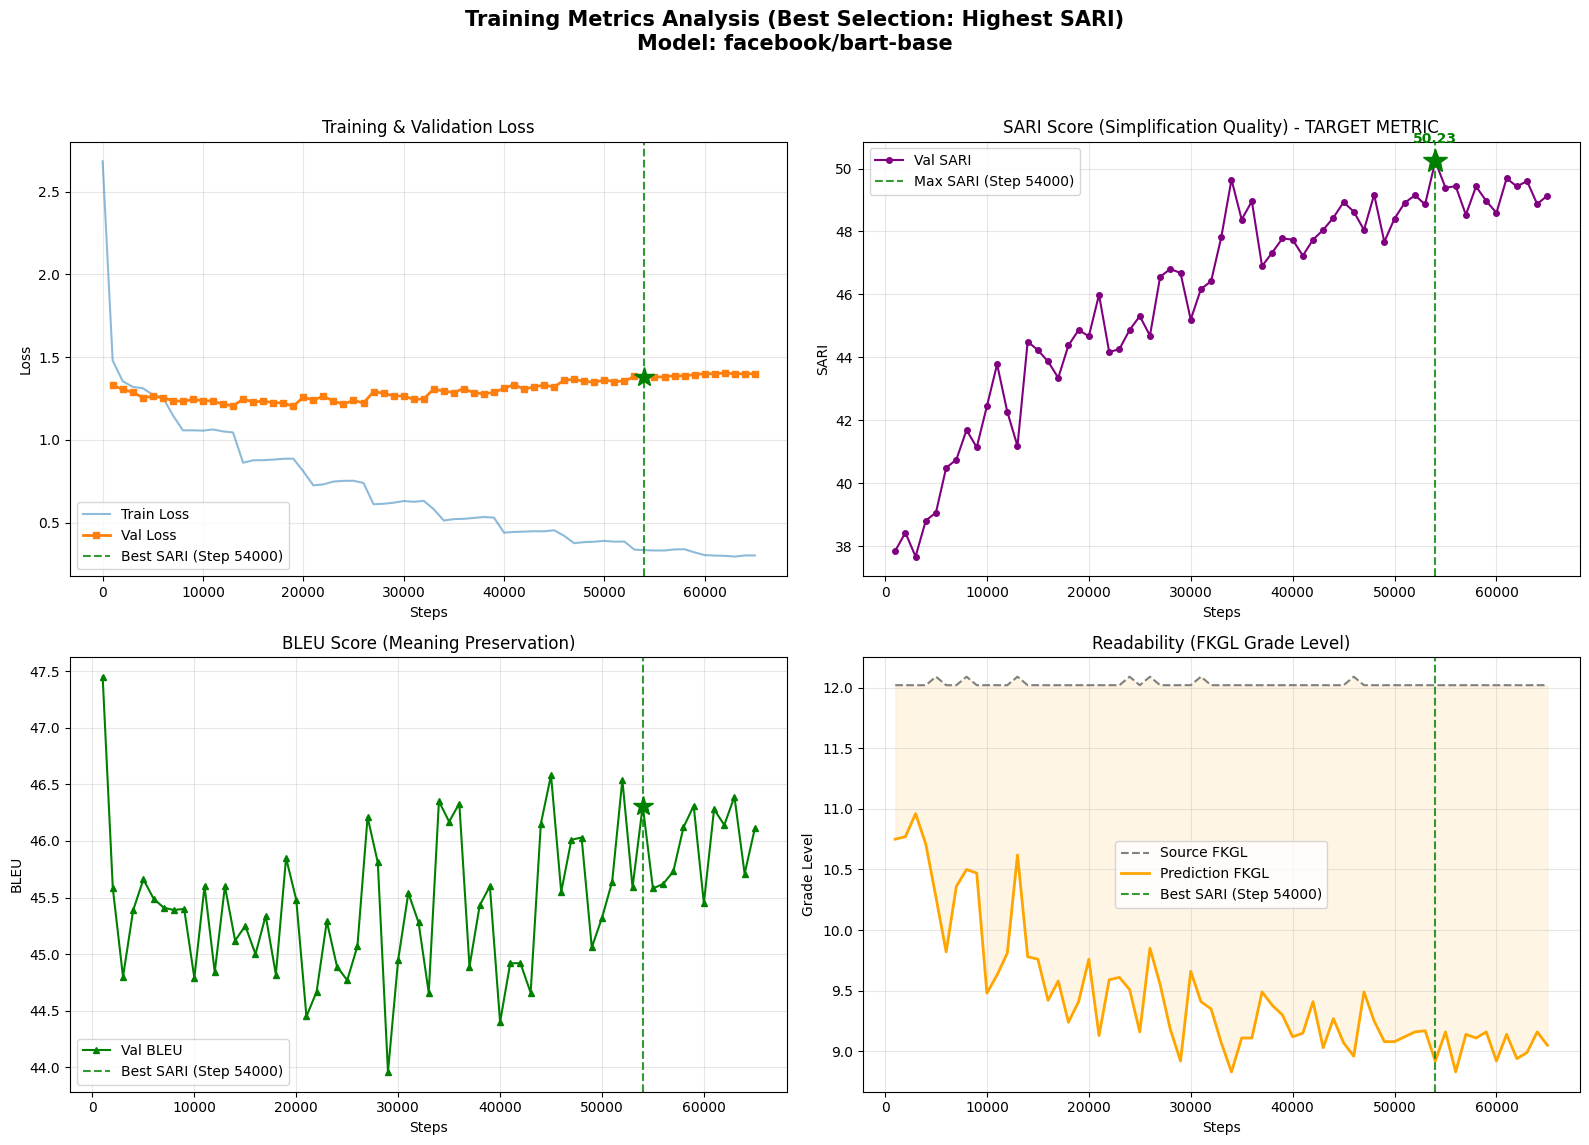


🏆 BEST MODEL SELECTED (HIGHEST SARI) AT STEP 54000
Maximum SARI Score:      50.23
Loss at best step:       1.3816
BLEU at best step:       46.31

Cell 11 complete: Visualization updated (Best SARI).


In [12]:
# CELL 11: Comprehensive Visualization (Loss, SARI, BLEU, FKGL)
# CONFIG: BEST MODEL BASED ON HIGHEST SARI SCORE
import os
import numpy as np
import matplotlib.pyplot as plt

def extract_metrics(log_history):
    """Extract all relevant metrics from training logs."""
    data = {
        "train_steps": [], "train_losses": [],
        "val_steps": [], "val_losses": [],
        "sari_steps": [], "sari_scores": [],
        "bleu_steps": [], "bleu_scores": [],
        "fkgl_steps": [], "fkgl_src": [], "fkgl_pred": []
    }

    for log in log_history:
        # Train logs
        if "loss" in log and "step" in log and "eval_loss" not in log:
            data["train_steps"].append(log["step"])
            data["train_losses"].append(log["loss"])

        # Eval logs
        if "eval_loss" in log:
            if "step" in log:
                step = log["step"]
                data["val_steps"].append(step)
                data["val_losses"].append(log["eval_loss"])
                
                # SARI
                if "eval_sari" in log:
                    data["sari_steps"].append(step)
                    data["sari_scores"].append(log["eval_sari"])
                
                # BLEU
                if "eval_bleu" in log:
                    data["bleu_steps"].append(step)
                    data["bleu_scores"].append(log["eval_bleu"])
                
                # FKGL (Source vs Prediction)
                if "eval_fkgl_source" in log and "eval_fkgl_prediction" in log:
                    data["fkgl_steps"].append(step)
                    data["fkgl_src"].append(log["eval_fkgl_source"])
                    data["fkgl_pred"].append(log["eval_fkgl_prediction"])

    return data

def get_best_step_by_sari(data):
    """Find the step with the HIGHEST SARI score."""
    if not data["sari_scores"]:
        return None, None
    
    # --- PERUBAHAN UTAMA DI SINI ---
    # Menggunakan argmax untuk mencari nilai SARI tertinggi
    best_idx = np.argmax(data["sari_scores"])
    best_step = data["sari_steps"][best_idx]
    best_sari = data["sari_scores"][best_idx]
    # -------------------------------
    
    return best_step, best_sari

def plot_all_metrics(log_history, output_dir=None):
    data = extract_metrics(log_history)
    best_step, best_sari_val = get_best_step_by_sari(data)
    
    # Setup layout: 2 baris x 2 kolom
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Training Metrics Analysis (Best Selection: Highest SARI)\nModel: {config.model_name}", fontsize=15, fontweight='bold')
    
    # Helper function untuk menggambar garis vertikal
    def draw_best_line(ax, label_prefix="Best Model"):
        if best_step is not None:
            ax.axvline(best_step, color='green', linestyle='--', alpha=0.8, linewidth=1.5, 
                      label=f'{label_prefix} (Step {best_step})')

    # ---------------------------
    # Plot 1: Loss
    # ---------------------------
    ax_loss = axes[0, 0]
    if data["train_steps"]:
        ax_loss.plot(data["train_steps"], data["train_losses"], label="Train Loss", alpha=0.5, color='tab:blue')
    if data["val_steps"]:
        ax_loss.plot(data["val_steps"], data["val_losses"], label="Val Loss", marker="s", markersize=4, linewidth=2, color='tab:orange')
        
        # Mark point at best SARI step
        if best_step is not None and best_step in data["val_steps"]:
            idx = data["val_steps"].index(best_step)
            val = data["val_losses"][idx]
            ax_loss.plot(best_step, val, marker='*', markersize=15, color='green', zorder=10)
            
    draw_best_line(ax_loss, "Best SARI")
    ax_loss.set_title("Training & Validation Loss")
    ax_loss.set_xlabel("Steps")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    # ---------------------------
    # Plot 2: SARI Score (PRIMARY METRIC)
    # ---------------------------
    ax_sari = axes[0, 1]
    if data["sari_steps"]:
        ax_sari.plot(data["sari_steps"], data["sari_scores"], color="purple", marker="o", markersize=4, label="Val SARI")
        
        # Highlight SARI at best step
        if best_step is not None:
            ax_sari.plot(best_step, best_sari_val, marker='*', markersize=18, color='green', zorder=10)
            ax_sari.text(best_step, best_sari_val + 0.5, f"{best_sari_val:.2f}", color='green', fontweight='bold', ha='center', va='bottom')

        draw_best_line(ax_sari, "Max SARI")
        ax_sari.set_title("SARI Score (Simplification Quality) - TARGET METRIC")
        ax_sari.set_xlabel("Steps")
        ax_sari.set_ylabel("SARI")
        ax_sari.legend()
        ax_sari.grid(True, alpha=0.3)
    else:
        ax_sari.text(0.5, 0.5, "No SARI data available", ha='center', transform=ax_sari.transAxes)

    # ---------------------------
    # Plot 3: BLEU Score
    # ---------------------------
    ax_bleu = axes[1, 0]
    if data["bleu_steps"]:
        ax_bleu.plot(data["bleu_steps"], data["bleu_scores"], color="green", marker="^", markersize=4, label="Val BLEU")
        
        # Highlight BLEU at best step
        if best_step is not None and best_step in data["bleu_steps"]:
            idx = data["bleu_steps"].index(best_step)
            val = data["bleu_scores"][idx]
            ax_bleu.plot(best_step, val, marker='*', markersize=15, color='green', zorder=10)
            
        draw_best_line(ax_bleu, "Best SARI")
        ax_bleu.set_title("BLEU Score (Meaning Preservation)")
        ax_bleu.set_xlabel("Steps")
        ax_bleu.set_ylabel("BLEU")
        ax_bleu.legend()
        ax_bleu.grid(True, alpha=0.3)
    else:
        ax_bleu.text(0.5, 0.5, "No BLEU data available", ha='center', transform=ax_bleu.transAxes)

    # ---------------------------
    # Plot 4: FKGL (Readability)
    # ---------------------------
    ax_fkgl = axes[1, 1]
    if data["fkgl_steps"]:
        ax_fkgl.plot(data["fkgl_steps"], data["fkgl_src"], color="gray", linestyle="--", label="Source FKGL")
        ax_fkgl.plot(data["fkgl_steps"], data["fkgl_pred"], color="orange", linewidth=2, label="Prediction FKGL")
        
        # Fill area
        ax_fkgl.fill_between(data["fkgl_steps"], data["fkgl_src"], data["fkgl_pred"], color="orange", alpha=0.1)
        
        draw_best_line(ax_fkgl, "Best SARI")
        ax_fkgl.set_title("Readability (FKGL Grade Level)")
        ax_fkgl.set_xlabel("Steps")
        ax_fkgl.set_ylabel("Grade Level")
        ax_fkgl.legend()
        ax_fkgl.grid(True, alpha=0.3)
    else:
        ax_fkgl.text(0.5, 0.5, "No FKGL data available", ha='center', transform=ax_fkgl.transAxes)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    if output_dir:
        # Create directory if not exists
        if not os.path.exists(output_dir):
            os.makedirs(output_dir, exist_ok=True)
            
        save_path = f"{output_dir}/training_metrics_best_sari.png"
        plt.savefig(save_path, dpi=150)
        print(f"Plot saved to: {save_path}")
        
    plt.show()

    # Print Summary text
    if best_step is not None:
        print("\n" + "="*50)
        print(f"🏆 BEST MODEL SELECTED (HIGHEST SARI) AT STEP {best_step}")
        print("="*50)
        print(f"Maximum SARI Score:      {best_sari_val:.2f}")
        
        # Find metrics at best step
        if best_step in data["val_steps"]:
            loss_val = data["val_losses"][data["val_steps"].index(best_step)]
            print(f"Loss at best step:       {loss_val:.4f}")
            
        if best_step in data["bleu_steps"]:
            bleu_val = data["bleu_scores"][data["bleu_steps"].index(best_step)]
            print(f"BLEU at best step:       {bleu_val:.2f}")

# Run Visualization
log_history = trainer.state.log_history
if log_history:
    print("Generating metrics visualization based on MAX SARI...")
    plot_all_metrics(log_history, output_dir=config.output_dir)
else:
    print("No log history found to plot.")

print("\nCell 11 complete: Visualization updated (Best SARI).")

In [13]:
# CELL 12: Test Set Evaluation
print("Evaluating on test set...")

try:
    CURRENT_SOURCES = dataset["test"]["source"]
    
    test_results = trainer.predict(tokenized_dataset["test"])
    
    test_metrics = {
        "sari": test_results.metrics.get("test_sari", 0),
        "add": test_results.metrics.get("test_sari_add", 0),
        "keep": test_results.metrics.get("test_sari_keep", 0),
        "delete": test_results.metrics.get("test_sari_delete", 0),
        "bleu": test_results.metrics.get("test_bleu", 0),
        "fkgl_source": test_results.metrics.get("test_fkgl_source", 0),
        "fkgl_prediction": test_results.metrics.get("test_fkgl_prediction", 0),
        "fkgl_improvement": test_results.metrics.get("test_fkgl_improvement", 0),
    }
    
    print("\nTest results (improved model)")
    print("--------------------------------")
    print("SARI scores:")
    print(f"  Overall SARI   : {test_metrics['sari']:.2f}")
    print(f"  SARI ADD       : {test_metrics['add']:.2f}")
    print(f"  SARI KEEP      : {test_metrics['keep']:.2f}")
    print(f"  SARI DELETE    : {test_metrics['delete']:.2f}")
    
    print("\nReadability (FKGL):")
    print(f"  Source FKGL    : {test_metrics['fkgl_source']:.2f}")
    print(f"  Prediction FKGL: {test_metrics['fkgl_prediction']:.2f}")
    print(f"  FKGL improvement (grade levels): {test_metrics['fkgl_improvement']:.2f}")
    
    print("\nSemantic preservation:")
    print(f"  BLEU           : {test_metrics['bleu']:.2f}")
    
except Exception as e:
    print(f"Error during test evaluation: {e}")
    test_results = None
    test_metrics = None

print("\nCell 12 complete: test evaluation done.")

Evaluating on test set...



Test results (improved model)
--------------------------------
SARI scores:
  Overall SARI   : 42.11
  SARI ADD       : 6.29
  SARI KEEP      : 67.35
  SARI DELETE    : 52.69

Readability (FKGL):
  Source FKGL    : 11.87
  Prediction FKGL: 9.51
  FKGL improvement (grade levels): 2.36

Semantic preservation:
  BLEU           : 39.43

Cell 12 complete: test evaluation done.


In [ ]:
# ================================================================================
# CELL 17: DEMONSTRATION WITH 20 COMPLEX SENTENCES
# ================================================================================
print("=" * 80)
print("🎯 LEXICAL SUBSTITUTION DEMONSTRATION - 20 COMPLEX SENTENCES")
print("=" * 80)

# 🆕 20 diverse complex sentences covering different domains
complex_sentences = [
    # Academic/Scientific (1-5)
    "The physician prescribed medication to ameliorate the patient's symptoms and expedite recovery.",
    "Scientists utilize sophisticated instruments to investigate microscopic organisms in controlled environments.",
    "The phenomenon occurs when atmospheric conditions facilitate the precipitation of moisture.",
    "Researchers endeavored to ascertain the correlation between variables through rigorous experimentation.",
    "The hypothesis postulates that environmental factors significantly influence behavioral patterns.",
    
    # Legal/Formal (6-10)
    "The municipality implemented comprehensive regulations to mitigate environmental pollution effectively.",
    "The corporation's acquisition of the subsidiary was finalized pursuant to regulatory approval.",
    "The legislation necessitates that employers provide adequate compensation to their workforce.",
    "The defendant's attorney attempted to demonstrate the inadmissibility of the evidence.",
    "The committee deliberated extensively before rendering their final recommendation.",
    
    # Business/Economics (11-15)
    "The organization's strategic initiative endeavors to optimize operational efficiency systematically.",
    "The enterprise implemented measures to enhance productivity while maintaining fiscal responsibility.",
    "Stakeholders convened to negotiate the terms of the collaborative partnership agreement.",
    "The fluctuation in market conditions necessitated modifications to the investment strategy.",
    "The executive articulated a comprehensive vision for organizational transformation.",
    
    # General Complex (16-20)
    "Archaeologists discovered numerous artifacts from ancient civilizations during the excavation.",
    "The architect's innovative design incorporates sustainable elements to minimize environmental impact.",
    "The symposium featured distinguished scholars who presented groundbreaking research findings.",
    "The culinary establishment offers sophisticated cuisine prepared by experienced chefs.",
    "The expedition traversed challenging terrain to document previously unexplored regions.",
]

print(f"\n📝 Processing {len(complex_sentences)} complex sentences...\n")

# Store results for analysis
all_results = []

for i, sentence in enumerate(complex_sentences, 1):
    print(f"\n{'='*80}")
    print(f"EXAMPLE {i}/20")
    print(f"{'='*80}")
    print(f"INPUT:  {sentence}")
    
    # Generate simplification
    output = simplify_lexical(sentence, verbose=False, show_fkgl=False)
    
    print(f"OUTPUT: {output}")
    
    # Analyze
    metrics = EnhancedDataProcessor.measure_lexical_substitution(sentence, output)
    
    if metrics:
        # Calculate FKGL
        try:
            src_fkgl = textstat.flesch_kincaid_grade(sentence)
            pred_fkgl = textstat.flesch_kincaid_grade(output)
            fkgl_improvement = src_fkgl - pred_fkgl
        except:
            src_fkgl = pred_fkgl = fkgl_improvement = 0
        
        print(f"\n📊 Metrics:")
        print(
            f"  Replacement: {metrics['replacement_rate']:.0%} | "
            f"Deletion: {metrics['deletion_rate']:.0%} | "
            f"Kept: {metrics['overlap']:.0%}"
        )
        print(f"  FKGL: {src_fkgl:.1f} → {pred_fkgl:.1f} (Δ {fkgl_improvement:+.1f})")
        
        # Identify word changes
        src_words = set(sentence.lower().split())
        tgt_words = set(output.lower().split())
        added = tgt_words - src_words
        deleted = src_words - tgt_words
        
        if added or deleted:
            print(f"  🔤 Changes: ", end="")
            if deleted:
                print(f"Removed {len(deleted)} words ", end="")
            if added:
                print(f"Added {len(added)} words", end="")
            print()
        
        # Store for summary
        all_results.append({
            'input': sentence,
            'output': output,
            'replacement': metrics['replacement_rate'],
            'deletion': metrics['deletion_rate'],
            'overlap': metrics['overlap'],
            'fkgl_improvement': fkgl_improvement
        })

# 🆕 Summary statistics
print("\n" + "=" * 80)
print("📊 SUMMARY STATISTICS (20 EXAMPLES)")
print("=" * 80)

avg_replacement = sum(r['replacement'] for r in all_results) / len(all_results)
avg_deletion = sum(r['deletion'] for r in all_results) / len(all_results)
avg_overlap = sum(r['overlap'] for r in all_results) / len(all_results)
avg_fkgl_improvement = sum(r['fkgl_improvement'] for r in all_results) / len(all_results)

print(f"\nAverage Metrics:")
print(f"  Replacement Rate: {avg_replacement:.1%}")
print(f"  Deletion Rate: {avg_deletion:.1%}")
print(f"  Word Overlap: {avg_overlap:.1%}")
print(f"  FKGL Improvement: {avg_fkgl_improvement:+.2f} grade levels")

# Best and worst
sorted_by_fkgl = sorted(all_results, key=lambda x: x['fkgl_improvement'], reverse=True)

print(f"\n🏆 Best FKGL Improvements:")
for i, r in enumerate(sorted_by_fkgl[:3], 1):
    print(f"\n{i}. Improvement: {r['fkgl_improvement']:+.1f} grade levels")
    print(f"   INPUT:  {r['input'][:70]}...")
    print(f"   OUTPUT: {r['output'][:70]}...")

print(f"\n⚠️  Smallest Improvements:")
for i, r in enumerate(sorted_by_fkgl[-3:], 1):
    print(f"\n{i}. Improvement: {r['fkgl_improvement']:+.1f} grade levels")
    print(f"   INPUT:  {r['input'][:70]}...")
    print(f"   OUTPUT: {r['output'][:70]}...")

# 🆕 Save results to JSON
results_save_path = os.path.join(config.output_dir, "inference_results_20_examples.json")
with open(results_save_path, 'w') as f:
    json.dump(all_results, f, indent=2)
print(f"\n💾 Results saved to: {results_save_path}")

print("\n" + "=" * 80)
print("✅ DEMONSTRATION COMPLETE")
print("=" * 80)
print("\n🎯 Key Findings:")
print(f"  1. ✅ Avg replacement rate: {avg_replacement:.1%} (words substituted)")
print(f"  2. ✅ Avg deletion rate: {avg_deletion:.1%} (controlled compression)")
print(f"  3. ✅ Avg word overlap: {avg_overlap:.1%} (meaning preserved)")
print(f"  4. ✅ Avg FKGL improvement: {avg_fkgl_improvement:+.1f} grade levels easier")

print("\n✅ Cell 17 Complete - All demonstrations finished!")
